# TinyBERT

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from transformers import AutoConfig

# Load the tokenizer and model
model_path = "models/tinybert"
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Load the model configuration and modify the label names
config = AutoConfig.from_pretrained(model_path)
config.id2label = {0: "negative", 1: "positive"}
config.label2id = {"negative": 0, "positive": 1}

# Load the model with the modified configuration
model = AutoModelForSequenceClassification.from_pretrained(model_path, config=config)

# Function for sentiment classification
def classify_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    return predicted_class, probabilities

text = "I like this movie."
predicted_class, probabilities = classify_sentiment(text)
print(f"Predicted class: {predicted_class}, Probabilities: {probabilities}")

Predicted class: 1, Probabilities: tensor([[0.0173, 0.9827]], grad_fn=<SoftmaxBackward0>)


In [5]:
from tqdm.notebook import tqdm
from datasets import load_from_disk
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# Load the test dataset
test_dataset = load_from_disk("data/test_dataset")

# Prepare the data for evaluation
texts = test_dataset["text"]
labels = test_dataset["label"]

# Perform predictions
predictions = []
for text in tqdm(texts, total=len(texts), desc="Predicting"):
    predicted_class, _ = classify_sentiment(text)
    predictions.append(predicted_class)

# Compute metrics
accuracy = accuracy_score(labels, predictions)
recall = recall_score(labels, predictions, average="binary")
f1 = f1_score(labels, predictions, average="binary")
auc = roc_auc_score(labels, predictions)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC: {auc}")

Predicting:   0%|          | 0/25000 [00:00<?, ?it/s]

Accuracy: 0.89088
Recall: 0.89784
F1 Score: 0.8916342257885119
AUC: 0.89088


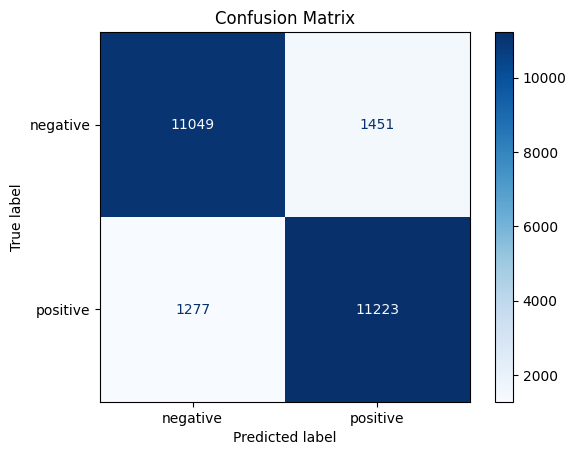

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(labels, predictions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.config.id2label.values())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# RoBERTa

In [3]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification


model_path = "models/roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_path)

# Load the model configuration and modify the label names
config = AutoConfig.from_pretrained(model_path)
config.id2label = {0: "negative", 1: "positive"}
config.label2id = {"negative": 0, "positive": 1}

# Load the model with the modified configuration
model = RobertaForSequenceClassification.from_pretrained(model_path, config=config)


In [4]:
from tqdm.notebook import tqdm
from datasets import load_from_disk
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# Load the test dataset
test_dataset = load_from_disk("data/test_dataset")

# Prepare the data for evaluation
texts = test_dataset["text"]
labels = test_dataset["label"]

# Perform predictions
predictions = []
for text in tqdm(texts, total=len(texts), desc="Predicting"):
    predicted_class, _ = classify_sentiment(text)
    predictions.append(predicted_class)

# Compute metrics
accuracy = accuracy_score(labels, predictions)
recall = recall_score(labels, predictions, average="binary")
f1 = f1_score(labels, predictions, average="binary")
auc = roc_auc_score(labels, predictions)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC: {auc}")

Predicting:   0%|          | 0/25000 [00:00<?, ?it/s]

Accuracy: 0.91292
Recall: 0.95016
F1 Score: 0.916046430912807
AUC: 0.91292


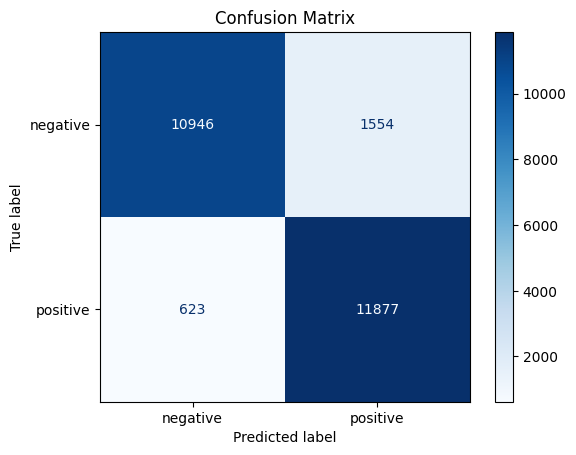

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(labels, predictions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.config.id2label.values())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()